In [3]:
from datasets import load_dataset

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

df = dataset['train'].to_pandas()

etiket_map = {0: 'negatif', 1: 'nötr', 2: 'pozitif'}
df['label_isim'] = df['label'].map(etiket_map)

print(f"Toplam tweet sayısı: {len(df)}")
df.head()

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Toplam tweet sayısı: 45615


,text,label,label_isim
0,"""QT @user In the original draft of the 7th boo...",2,pozitif
1,"""Ben Smith / Smith (concussion) remains out of...",1,nötr
2,Sorry bout the stream last night I crashed out...,1,nötr
3,Chase Headley's RBI double in the 8th inning o...,1,nötr
4,@user Alciato: Bee will invest 150 million in ...,2,pozitif


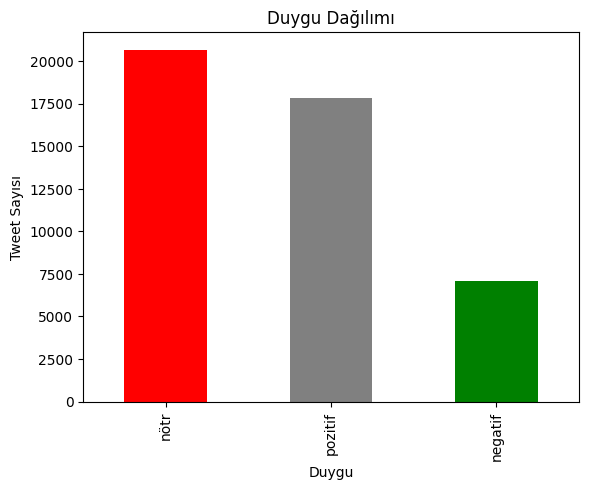

label_isim
nötr       20673
pozitif    17849
negatif     7093
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt

df['label_isim'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Duygu Dağılımı')
plt.xlabel('Duygu')
plt.ylabel('Tweet Sayısı')
plt.show()

print(df['label_isim'].value_counts())

In [5]:
from sklearn.model_selection import train_test_split

df_sample = df.sample(n=15000, random_state=42).reset_index(drop=True)

X = df_sample['text']
y = df_sample['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim seti: {len(X_train)}, Test seti: {len(X_test)}")

Eğitim seti: 12000, Test seti: 3000


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF matris boyutu: {X_train_tfidf.shape}")

TF-IDF matris boyutu: (12000, 5000)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

ml_model = LogisticRegression(max_iter=1000)
ml_model.fit(X_train_tfidf, y_train)

y_pred_ml = ml_model.predict(X_test_tfidf)
ml_accuracy = accuracy_score(y_test, y_pred_ml)

print(f"ML (TF-IDF + Logistic Regression) Doğruluk Oranı: {ml_accuracy:.2%}")

ML (TF-IDF + Logistic Regression) Doğruluk Oranı: 64.27%


In [8]:
sonuclar = {}
sonuclar['ML (TF-IDF + LogReg)'] = ml_accuracy
print(sonuclar)

{'ML (TF-IDF + LogReg)': 0.6426666666666667}


şimdi ise CNN ile devam edicez


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_kelime_sayisi = 5000
max_uzunluk = 30

tokenizer = Tokenizer(num_words=max_kelime_sayisi, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_uzunluk, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_uzunluk, padding='post', truncating='post')

print(f"Eğitim verisi boyutu: {X_train_pad.shape}")
print(f"Örnek bir tweet (sayı dizisi): {X_train_pad[0]}")

Eğitim verisi boyutu: (12000, 30)
Örnek bir tweet (sayı dizisi): [2217 2218 1446    1  151  104  335   64   33  332   23 2601    2  335
 1447   10 2858    1   67 4262 1201    0    0    0    0    0    0    0
    0    0]


In [10]:
import torch
import torch.nn as nn

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv1 = nn.Conv1d(embed_dim, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

model_cnn = TextCNN(vocab_size=max_kelime_sayisi, embed_dim=64, num_classes=3)
print(model_cnn)

TextCNN(
  (embedding): Embedding(5000, 64)
  (conv1): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)


In [11]:
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader

train_dataset_cnn = TensorDataset(X_train_tensor, y_train_tensor)
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=64, shuffle=True)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    for texts, labels in train_loader_cnn:
        outputs = model_cnn(texts)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Ortalama Loss: {total_loss/len(train_loader_cnn):.4f}")

Epoch 1/5, Ortalama Loss: 1.0106
Epoch 2/5, Ortalama Loss: 0.9240
Epoch 3/5, Ortalama Loss: 0.8480
Epoch 4/5, Ortalama Loss: 0.7744
Epoch 5/5, Ortalama Loss: 0.7016


In [13]:
model_cnn.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model_cnn(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    total = y_test_tensor.size(0)
    correct = (predicted == y_test_tensor).sum().item()

cnn_accuracy = correct / total
print(f"CNN (Text CNN) Doğruluk Oranı: {cnn_accuracy:.2%}")

sonuclar['CNN (Text CNN)'] = cnn_accuracy
print(sonuclar)

CNN (Text CNN) Doğruluk Oranı: 56.90%
{'ML (TF-IDF + LogReg)': 0.6426666666666667, 'CNN (Text CNN)': 0.569}


İlginç bir sonuç çıktı dostum, dürüstçe yorumlayalım — çünkü bu da gerçek veri biliminin bir parçası, her zaman "beklenen" sonuç çıkmaz.

Sonuçları Karşılaştıralım
ML (TF-IDF + Logistic Regression): %64.27
CNN (Text CNN): %56.90

CNN, ML'den daha düşük çıktı! İlk bakışta "CNN daha güçlü değil miydi" diye şaşırabilirsin, ama bunun gayet mantıklı sebepleri var — tıpkı Titanic'te Random Forest'ın Logistic Regression'ı geçememesi gibi.

Neden CNN Daha Düşük Çıktı?

1. Embedding'ler sıfırdan (rastgele) öğreniliyor
CNN'deki embedding katmanı, bu 15.000 tweet'lik küçük veriyle sıfırdan kelime anlamlarını öğrenmeye çalışıyor. Bu, çok az veri — gerçek dünyada CNN'ler genelde milyonlarca cümleyle eğitilir ki embedding'ler anlamlı hale gelsin. TF-IDF ise böyle bir "öğrenme" gerektirmiyor, direkt istatistiksel bir hesaplama yapıyor, bu yüzden az veride daha "garantili" çalışıyor.

2. Sadece 5 epoch, küçük veri
CNN'in gerçek potansiyelini göstermesi için daha fazla epoch ve/veya daha fazla veri gerekebilirdi — bugünkü amacımız "mükemmel sonuç almak" değil, mekanizmanın nasıl çalıştığını görmekti, ki bunu başardık.

3. TF-IDF, bu problem için zaten güçlü bir yöntem
Duygu analizi gibi bazı problemlerde, hangi kelimelerin var olduğu (TF-IDF'in yaptığı) bazen kelime sırasından (CNN'in yakaladığı) daha belirleyici olabilir — örneğin "harika", "berbat" gibi kelimeler tek başına bile çok güçlü sinyaller.

sıra da LLM yaklasımı var onu inceleyelim bi de


In [14]:
!pip install transformers --quiet

from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

ornek = sentiment_pipeline("I love this so much!")
print(ornek)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.9832356572151184}]


In [15]:
import numpy as np

test_ornekleri = X_test.tolist()[:1000]
gercek_etiketler = y_test.tolist()[:1000]

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

tahminler = []
for tweet in test_ornekleri:
    sonuc = sentiment_pipeline(tweet[:512])[0]
    tahminler.append(label_map[sonuc['label']])

llm_accuracy = accuracy_score(gercek_etiketler, tahminler)
print(f"LLM (Önceden Eğitilmiş Transformer) Doğruluk Oranı: {llm_accuracy:.2%}")

sonuclar['LLM (Pretrained Transformer)'] = llm_accuracy
print(sonuclar)

LLM (Önceden Eğitilmiş Transformer) Doğruluk Oranı: 79.60%
{'ML (TF-IDF + LogReg)': 0.6426666666666667, 'CNN (Text CNN)': 0.569, 'LLM (Pretrained Transformer)': 0.796}


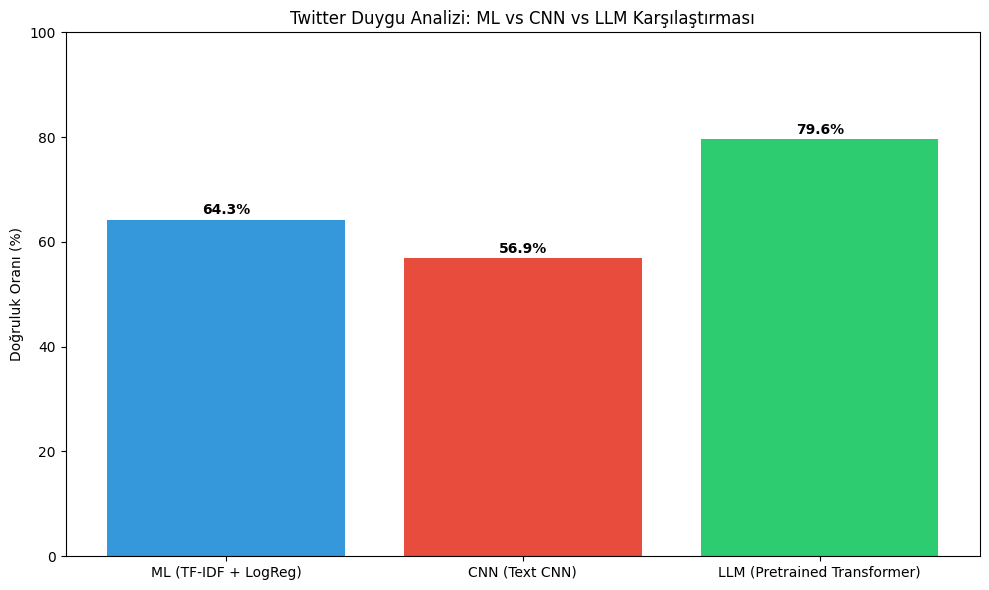

In [16]:
import matplotlib.pyplot as plt

yontemler = list(sonuclar.keys())
degerler = [v*100 for v in sonuclar.values()]

plt.figure(figsize=(10, 6))
bars = plt.bar(yontemler, degerler, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.ylabel('Doğruluk Oranı (%)')
plt.title('Twitter Duygu Analizi: ML vs CNN vs LLM Karşılaştırması')
plt.ylim(0, 100)

for bar, deger in zip(bars, degerler):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{deger:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##  Twitter Duygu Analizi: ML vs CNN vs LLM Karşılaştırmalı Proje

Bugün öğretmenimin verdiği görev üzerine, şu ana kadar öğrendiğim üç farklı yaklaşımı — klasik makine öğrenmesi, derin öğrenme (CNN) ve büyük dil modelleri (LLM) — aynı problem üzerinde, tek bir notebook'ta karşılaştırma fırsatı buldum. Bu proje benim için gerçek bir "büyük resmi görme" anı oldu; çünkü bugüne kadar bu üç konuyu ayrı ayrı öğrenmiştim, ilk kez hepsini yan yana koyup birbirleriyle yarıştırdım.

### Problem: Twitter Gönderilerinde Duygu Analizi

Amaç basitti ama etkileyiciydi: bir tweet'in **negatif, nötr ya da pozitif** olduğunu tahmin eden bir sistem kurmak. Veri seti olarak Cardiff Üniversitesi'nin hazırladığı, gerçek tweet'lerden oluşan **TweetEval** veri setini kullandım (45.615 tweet).

### Yaklaşım 1: Klasik Makine Öğrenmesi (TF-IDF + Logistic Regression)

İlk olarak, Titanic projemde öğrendiğim Logistic Regression'ı metin verisine uyguladım. Tabii metni direkt modele veremediğim için, önce **TF-IDF** tekniğiyle kelimeleri sayısal önem skorlarına çevirdim — hangi kelimenin bir tweet'te ne kadar "ayırt edici" olduğunu hesaplayan bir yöntem. Sonuç: **%64.27 doğruluk.** Basit ama şaşırtıcı derecede güçlü bir başlangıç.

### Yaklaşım 2: Derin Öğrenme (Text CNN)

CNN'i daha önce sadece görüntülerde (MNIST, Fashion-MNIST) kullanmıştım. Bugün, aynı "filtre ile örüntü arama" mantığının **metinde de** işleyebildiğini gördüm — bu sefer 2 boyutlu değil, 1 boyutlu bir filtre (Conv1d), kelimelerin üzerinde kayarak "3'lü kelime grupları" arasındaki ilişkiyi yakalamaya çalıştı. Sonuç: **%56.90 doğruluk.**

İlk başta bunun ML'den düşük çıkması beni şaşırttı, ama sonra nedenini anladım: CNN'in kelime anlamlarını (embedding) **sıfırdan, sadece 15.000 tweet'ten** öğrenmesi gerekiyordu — bu, gerçek bir dil anlayışı geliştirmek için çok az bir veri. Bu bana önemli bir ders verdi: **her zaman en "modern" yöntem en iyi sonucu vermez**, veri miktarı ve problem tipi çok belirleyici.

### Yaklaşım 3: LLM (Önceden Eğitilmiş Transformer)

Son olarak, sıfırdan hiçbir şey eğitmeden, Hugging Face üzerinden **Twitter verisiyle önceden eğitilmiş bir RoBERTa modelini** kullandım. Bu model, muhtemelen milyonlarca gerçek tweet'ten dil yapısını ve duygu ifadelerini zaten öğrenmiş durumdaydı — ben sadece onu "kiraladım" diyebilirim. Sonuç: **%79.60 doğruluk**, açık ara en iyi performans.

### Sonuçların Karşılaştırması

| Yöntem | Doğruluk |
|---|---|
| ML (TF-IDF + Logistic Regression) | %64.27 |
| CNN (Text CNN, sıfırdan eğitilmiş) | %56.90 |
| **LLM (Önceden Eğitilmiş Transformer)** | **%79.60** |

### Çıkardığım Genel Ders

Bu proje bana, bugüne kadar öğrendiğim üç farklı paradigmanın birbirine göre avantaj ve dezavantajlarını **somut sayılarla** gösterdi:

- **Klasik ML**, az veriyle bile hızlı ve şaşırtıcı derecede güçlü sonuçlar verebiliyor.
- **Sıfırdan eğitilen derin öğrenme modelleri**, gerçekten güçlü olabilmek için **çok daha fazla veriye** ihtiyaç duyuyor — bugünkü 15.000 tweet, bir CNN'in potansiyelini göstermesi için yeterli değildi.
- **Önceden eğitilmiş büyük modeller (LLM'ler)**, milyonlarca veriden öğrendikleri genel dil bilgisini bize "hazır" sundukları için, küçük bir projede bile en güçlü sonucu verebiliyorlar. Bu, modern yapay zekanın en büyük gücü: **transfer learning** — başkasının öğrendiğini, kendi problemine aktarabilmek.

Bugün, üç haftadır ayrı ayrı öğrendiğim konuları ilk kez bir arada, aynı problem üzerinde test ederek, aralarındaki farkı sadece teoride değil, **kendi gözlerimle, kendi sayılarımla** görmüş oldum.